## Evaluate decision tree

In [1]:
from pathlib import Path
import pandas as pd
import numpy as np

BASE = Path("/data/shared/fsibilla/clean_code/Q1/decision_supp_model/tree")

pred = pd.read_csv(BASE / "reg_test_predictions.csv")
fold = pd.read_csv(BASE / "reg_fold_test_metrics.csv")

print(pred.shape)
print(pred.columns.tolist())
print(fold.shape)
display(pred.head())
display(fold.head())

(2860, 13)
['experiment', 'adm1', 'variable', 'psu_num', 'variability_intrinsic_mean', 'n_train_mean', 'true_improvement_mean', 'true_improvement_std', 'outer_test_experiment', 'model_path', 'best_params', 'pred_improvement_mean', 'pred_improvement_std']
(8, 15)


,experiment,adm1,variable,psu_num,variability_intrinsic_mean,n_train_mean,true_improvement_mean,true_improvement_std,outer_test_experiment,model_path,best_params,pred_improvement_mean,pred_improvement_std
0,eth_micron,Addis Ababa,avg_adult_education,1,0.876903,15.0,0.590759,0.409287,eth_micron,/data/shared/fsibilla/clean_code/Q1/decision_s...,"{""max_depth"": 4, ""min_samples_leaf"": 5, ""min_s...",0.336685,0.138347
1,eth_micron,Addis Ababa,avg_adult_education,2,0.884816,29.6,0.516941,0.348304,eth_micron,/data/shared/fsibilla/clean_code/Q1/decision_s...,"{""max_depth"": 4, ""min_samples_leaf"": 5, ""min_s...",0.336685,0.138347
2,eth_micron,Addis Ababa,avg_adult_education,4,0.743971,50.2,0.465627,0.181572,eth_micron,/data/shared/fsibilla/clean_code/Q1/decision_s...,"{""max_depth"": 4, ""min_samples_leaf"": 5, ""min_s...",0.288191,0.119808
3,eth_micron,Addis Ababa,avg_adult_education,8,0.621071,118.2,0.449265,0.160634,eth_micron,/data/shared/fsibilla/clean_code/Q1/decision_s...,"{""max_depth"": 4, ""min_samples_leaf"": 5, ""min_s...",0.288191,0.119808
4,eth_micron,Addis Ababa,fe_ai,1,0.601189,15.0,-0.115664,0.298354,eth_micron,/data/shared/fsibilla/clean_code/Q1/decision_s...,"{""max_depth"": 4, ""min_samples_leaf"": 5, ""min_s...",0.133249,0.108868


,outer_test_experiment,n_train_rows,n_test_rows,n_train_experiments,n_test_experiments,best_params,model_path,test_improvement_mean_mae,test_improvement_mean_rmse,test_improvement_mean_r2,test_improvement_std_mae,test_improvement_std_rmse,test_improvement_std_r2,test_mean_mae_across_targets,test_mean_rmse_across_targets
0,eth_micron,2552,308,7,1,"{""max_depth"": 4, ""min_samples_leaf"": 5, ""min_s...",/data/shared/fsibilla/clean_code/Q1/decision_s...,0.133830,0.182501,0.234325,0.079468,0.129421,-0.203897,0.106649,0.155961
1,lka_micron,2608,252,7,1,"{""max_depth"": 4, ""min_samples_leaf"": 10, ""min_...",/data/shared/fsibilla/clean_code/Q1/decision_s...,0.072919,0.094098,0.062742,0.039585,0.057554,0.127469,0.056252,0.075826
2,lka_vam,2644,216,7,1,"{""max_depth"": 4, ""min_samples_leaf"": 10, ""min_...",/data/shared/fsibilla/clean_code/Q1/decision_s...,0.072807,0.096474,-0.809509,0.036306,0.046799,0.210562,0.054556,0.071636
3,moz_vam,2640,220,7,1,"{""max_depth"": 4, ""min_samples_leaf"": 10, ""min_...",/data/shared/fsibilla/clean_code/Q1/decision_s...,0.071345,0.095278,-1.275717,0.044659,0.059245,-0.154714,0.058002,0.077261
4,nga_micron,1824,1036,7,1,"{""max_depth"": 4, ""min_samples_leaf"": 10, ""min_...",/data/shared/fsibilla/clean_code/Q1/decision_s...,0.105716,0.143363,0.093301,0.041572,0.056318,-0.106409,0.073644,0.099840


In [2]:
cols = [
    "outer_test_experiment",
    "test_improvement_mean_mae",
    "test_improvement_mean_rmse",
    "test_improvement_mean_r2",
    "test_improvement_std_mae",
    "test_improvement_std_rmse",
    "test_improvement_std_r2",
]
display(fold[cols].sort_values("outer_test_experiment"))

,outer_test_experiment,test_improvement_mean_mae,test_improvement_mean_rmse,test_improvement_mean_r2,test_improvement_std_mae,test_improvement_std_rmse,test_improvement_std_r2
0,eth_micron,0.133830,0.182501,0.234325,0.079468,0.129421,-0.203897
1,lka_micron,0.072919,0.094098,0.062742,0.039585,0.057554,0.127469
2,lka_vam,0.072807,0.096474,-0.809509,0.036306,0.046799,0.210562
3,moz_vam,0.071345,0.095278,-1.275717,0.044659,0.059245,-0.154714
4,nga_micron,0.105716,0.143363,0.093301,0.041572,0.056318,-0.106409
5,nga_mics,0.105095,0.137748,0.241719,0.040358,0.050419,-0.203472
6,yem_mvam,0.062335,0.088537,-0.102853,0.042873,0.047887,-2.990780
7,zwe_mics,0.141591,0.179256,0.264654,0.074257,0.131725,-0.097364


In [3]:
summary = pd.DataFrame({
    "metric": [
        "mean MAE improvement_mean",
        "mean RMSE improvement_mean",
        "mean R2 improvement_mean",
        "mean MAE improvement_std",
        "mean RMSE improvement_std",
        "mean R2 improvement_std",
    ],
    "value": [
        fold["test_improvement_mean_mae"].mean(),
        fold["test_improvement_mean_rmse"].mean(),
        fold["test_improvement_mean_r2"].mean(),
        fold["test_improvement_std_mae"].mean(),
        fold["test_improvement_std_rmse"].mean(),
        fold["test_improvement_std_r2"].mean(),
    ]
})
display(summary)

,metric,value
0,mean MAE improvement_mean,0.095705
1,mean RMSE improvement_mean,0.127157
2,mean R2 improvement_mean,-0.161417
3,mean MAE improvement_std,0.049885
4,mean RMSE improvement_std,0.072421
5,mean R2 improvement_std,-0.427326


In [4]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

for target in ["improvement_mean", "improvement_std"]:
    y_true = pred[f"true_{target}"]
    y_pred = pred[f"pred_{target}"]
    
    print(f"\nTARGET: {target}")
    print("MAE :", mean_absolute_error(y_true, y_pred))
    print("RMSE:", rmse(y_true, y_pred))
    print("R2  :", r2_score(y_true, y_pred))


TARGET: improvement_mean
MAE : 0.09812883137989109
RMSE: 0.13502139659577664
R2  : 0.1989753806694452

TARGET: improvement_std
MAE : 0.04662065206692856
RMSE: 0.07081229532949639
R2  : 0.04921283220503214


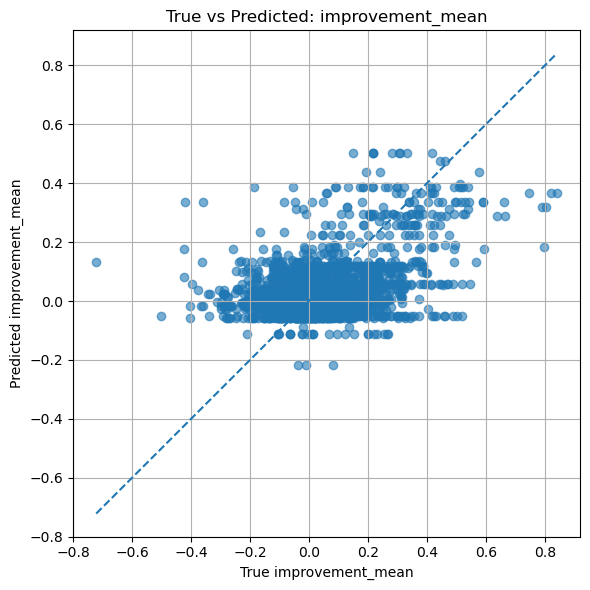

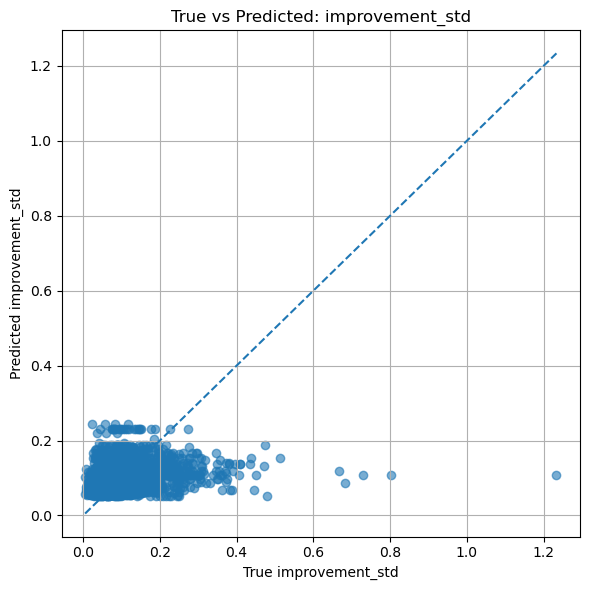

In [5]:
import matplotlib.pyplot as plt

for target in ["improvement_mean", "improvement_std"]:
    x = pred[f"true_{target}"]
    y = pred[f"pred_{target}"]
    
    mn = min(x.min(), y.min())
    mx = max(x.max(), y.max())
    
    plt.figure(figsize=(6, 6))
    plt.scatter(x, y, alpha=0.6)
    plt.plot([mn, mx], [mn, mx], linestyle="--")
    plt.xlabel(f"True {target}")
    plt.ylabel(f"Predicted {target}")
    plt.title(f"True vs Predicted: {target}")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

In [6]:
for target in ["improvement_mean", "improvement_std"]:
    tmp = pred.groupby("outer_test_experiment").apply(
        lambda g: pd.Series({
            "mae": np.mean(np.abs(g[f"true_{target}"] - g[f"pred_{target}"])),
            "rmse": np.sqrt(np.mean((g[f"true_{target}"] - g[f"pred_{target}"])**2)),
        })
    ).reset_index()

    print(f"\nPerformance by experiment for {target}")
    display(tmp.sort_values("mae"))


Performance by experiment for improvement_mean


/tmp/ipykernel_444264/149505076.py:2: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  tmp = pred.groupby("outer_test_experiment").apply(


,outer_test_experiment,mae,rmse
6,yem_mvam,0.062335,0.088537
3,moz_vam,0.071345,0.095278
2,lka_vam,0.072807,0.096474
1,lka_micron,0.072919,0.094098
5,nga_mics,0.105095,0.137748
4,nga_micron,0.105716,0.143363
0,eth_micron,0.133830,0.182501
7,zwe_mics,0.141591,0.179256



Performance by experiment for improvement_std


/tmp/ipykernel_444264/149505076.py:2: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  tmp = pred.groupby("outer_test_experiment").apply(


,outer_test_experiment,mae,rmse
2,lka_vam,0.036306,0.046799
1,lka_micron,0.039585,0.057554
5,nga_mics,0.040358,0.050419
4,nga_micron,0.041572,0.056318
6,yem_mvam,0.042873,0.047887
3,moz_vam,0.044659,0.059245
7,zwe_mics,0.074257,0.131725
0,eth_micron,0.079468,0.129421


## Classification

In [7]:
from pathlib import Path
import pandas as pd
import numpy as np

BASE = Path("/data/shared/fsibilla/clean_code/Q1/decision_supp_model/tree")

cls_pred = pd.read_csv(BASE / "cls_test_predictions.csv")
cls_fold = pd.read_csv(BASE / "cls_fold_test_metrics.csv")

print(cls_pred.shape)
print(cls_pred.columns.tolist())
print(cls_fold.shape)
display(cls_pred.head())
display(cls_fold.head())

(2860, 14)
['experiment', 'adm1', 'variable', 'psu_num', 'variability_intrinsic_mean', 'n_train_mean', 'outer_test_experiment', 'model_path', 'best_params', 'true_target_improvement_positive', 'pred_target_improvement_positive', 'pred_proba_target_improvement_positive', 'true_improvement_mean', 'true_improvement_std']
(8, 14)


,experiment,adm1,variable,psu_num,variability_intrinsic_mean,n_train_mean,outer_test_experiment,model_path,best_params,true_target_improvement_positive,pred_target_improvement_positive,pred_proba_target_improvement_positive,true_improvement_mean,true_improvement_std
0,eth_micron,Addis Ababa,avg_adult_education,1,0.876903,15.0,eth_micron,/data/shared/fsibilla/clean_code/Q1/decision_s...,"{""max_depth"": 4, ""min_samples_leaf"": 10, ""min_...",1,1,0.649023,0.590759,0.409287
1,eth_micron,Addis Ababa,avg_adult_education,2,0.884816,29.6,eth_micron,/data/shared/fsibilla/clean_code/Q1/decision_s...,"{""max_depth"": 4, ""min_samples_leaf"": 10, ""min_...",1,1,0.922915,0.516941,0.348304
2,eth_micron,Addis Ababa,avg_adult_education,4,0.743971,50.2,eth_micron,/data/shared/fsibilla/clean_code/Q1/decision_s...,"{""max_depth"": 4, ""min_samples_leaf"": 10, ""min_...",1,1,0.922915,0.465627,0.181572
3,eth_micron,Addis Ababa,avg_adult_education,8,0.621071,118.2,eth_micron,/data/shared/fsibilla/clean_code/Q1/decision_s...,"{""max_depth"": 4, ""min_samples_leaf"": 10, ""min_...",1,1,0.958441,0.449265,0.160634
4,eth_micron,Addis Ababa,fe_ai,1,0.601189,15.0,eth_micron,/data/shared/fsibilla/clean_code/Q1/decision_s...,"{""max_depth"": 4, ""min_samples_leaf"": 10, ""min_...",0,1,0.649023,-0.115664,0.298354


,outer_test_experiment,n_train_rows,n_test_rows,n_train_experiments,n_test_experiments,best_params,model_path,test_roc_auc,test_accuracy,test_precision,test_recall,test_f1,test_positive_rate_true,test_positive_rate_pred
0,eth_micron,2552,308,7,1,"{""max_depth"": 4, ""min_samples_leaf"": 10, ""min_...",/data/shared/fsibilla/clean_code/Q1/decision_s...,0.700683,0.668831,0.640351,0.879518,0.741117,0.538961,0.740260
1,lka_micron,2608,252,7,1,"{""max_depth"": 4, ""min_samples_leaf"": 10, ""min_...",/data/shared/fsibilla/clean_code/Q1/decision_s...,0.672684,0.738095,0.537037,0.414286,0.467742,0.277778,0.214286
2,lka_vam,2644,216,7,1,"{""max_depth"": 4, ""min_samples_leaf"": 5, ""min_s...",/data/shared/fsibilla/clean_code/Q1/decision_s...,0.559957,0.708333,0.378378,0.259259,0.307692,0.250000,0.171296
3,moz_vam,2640,220,7,1,"{""max_depth"": 4, ""min_samples_leaf"": 5, ""min_s...",/data/shared/fsibilla/clean_code/Q1/decision_s...,0.487696,0.709091,0.416667,0.357143,0.384615,0.254545,0.218182
4,nga_micron,1824,1036,7,1,"{""max_depth"": 4, ""min_samples_leaf"": 10, ""min_...",/data/shared/fsibilla/clean_code/Q1/decision_s...,0.664275,0.627413,0.735060,0.593248,0.656584,0.600386,0.484556


In [8]:
cols = [
    "outer_test_experiment",
    "test_roc_auc",
    "test_accuracy",
    "test_precision",
    "test_recall",
    "test_f1",
    "test_positive_rate_true",
    "test_positive_rate_pred",
]
display(cls_fold[cols].sort_values("outer_test_experiment"))

,outer_test_experiment,test_roc_auc,test_accuracy,test_precision,test_recall,test_f1,test_positive_rate_true,test_positive_rate_pred
0,eth_micron,0.700683,0.668831,0.640351,0.879518,0.741117,0.538961,0.740260
1,lka_micron,0.672684,0.738095,0.537037,0.414286,0.467742,0.277778,0.214286
2,lka_vam,0.559957,0.708333,0.378378,0.259259,0.307692,0.250000,0.171296
3,moz_vam,0.487696,0.709091,0.416667,0.357143,0.384615,0.254545,0.218182
4,nga_micron,0.664275,0.627413,0.735060,0.593248,0.656584,0.600386,0.484556
5,nga_mics,0.716254,0.722973,0.766272,0.854785,0.808112,0.682432,0.761261
6,yem_mvam,0.644663,0.553030,0.771429,0.197080,0.313953,0.518939,0.132576
7,zwe_mics,0.754113,0.641667,0.521127,0.804348,0.632479,0.383333,0.591667


In [9]:
summary = pd.DataFrame({
    "metric": [
        "mean ROC AUC",
        "mean accuracy",
        "mean precision",
        "mean recall",
        "mean F1",
    ],
    "value": [
        cls_fold["test_roc_auc"].mean(),
        cls_fold["test_accuracy"].mean(),
        cls_fold["test_precision"].mean(),
        cls_fold["test_recall"].mean(),
        cls_fold["test_f1"].mean(),
    ]
})
display(summary)

,metric,value
0,mean ROC AUC,0.650041
1,mean accuracy,0.671179
2,mean precision,0.595790
3,mean recall,0.544958
4,mean F1,0.539037


In [10]:
from sklearn.metrics import roc_auc_score, accuracy_score, precision_score, recall_score, f1_score

y_true = cls_pred["true_target_improvement_positive"].astype(int)
y_pred = cls_pred["pred_target_improvement_positive"].astype(int)
y_score = cls_pred["pred_proba_target_improvement_positive"].astype(float)

print("Overall ROC AUC :", roc_auc_score(y_true, y_score))
print("Overall accuracy:", accuracy_score(y_true, y_pred))
print("Overall precision:", precision_score(y_true, y_pred, zero_division=0))
print("Overall recall   :", recall_score(y_true, y_pred, zero_division=0))
print("Overall F1       :", f1_score(y_true, y_pred, zero_division=0))
print("True positive rate:", y_true.mean())
print("Pred positive rate:", y_pred.mean())

Overall ROC AUC : 0.6730982955735001
Overall accuracy: 0.6625874125874126
Overall precision: 0.6862147753236862
Overall recall   : 0.6196698762035764
Overall F1       : 0.6512468377303939
True positive rate: 0.5083916083916084
Pred positive rate: 0.4590909090909091


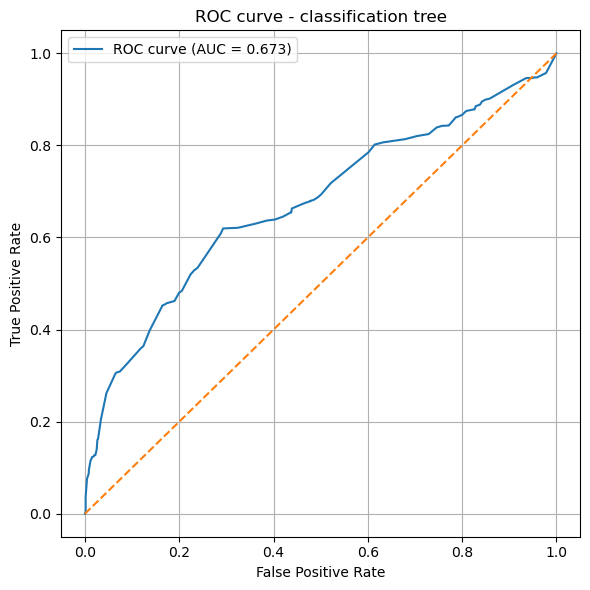

In [11]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, roc_auc_score

y_true = cls_pred["true_target_improvement_positive"].astype(int)
y_score = cls_pred["pred_proba_target_improvement_positive"].astype(float)

fpr, tpr, thresholds = roc_curve(y_true, y_score)
auc = roc_auc_score(y_true, y_score)

plt.figure(figsize=(6, 6))
plt.plot(fpr, tpr, label=f"ROC curve (AUC = {auc:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC curve - classification tree")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

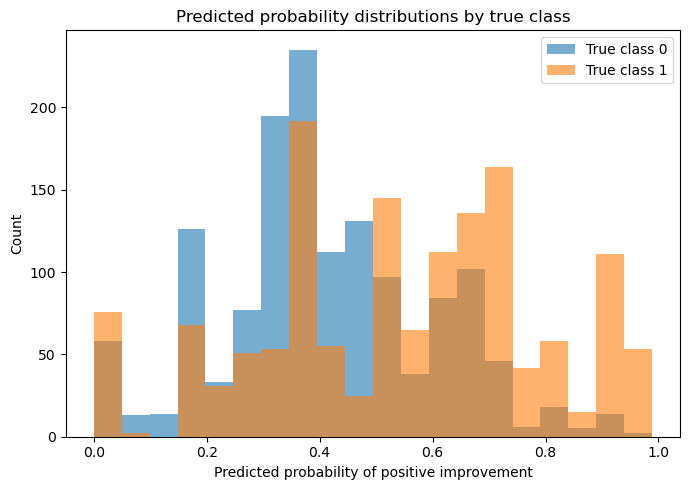

In [12]:
plt.figure(figsize=(7, 5))
plt.hist(
    cls_pred.loc[cls_pred["true_target_improvement_positive"] == 0, "pred_proba_target_improvement_positive"],
    bins=20,
    alpha=0.6,
    label="True class 0"
)
plt.hist(
    cls_pred.loc[cls_pred["true_target_improvement_positive"] == 1, "pred_proba_target_improvement_positive"],
    bins=20,
    alpha=0.6,
    label="True class 1"
)
plt.xlabel("Predicted probability of positive improvement")
plt.ylabel("Count")
plt.title("Predicted probability distributions by true class")
plt.legend()
plt.tight_layout()
plt.show()

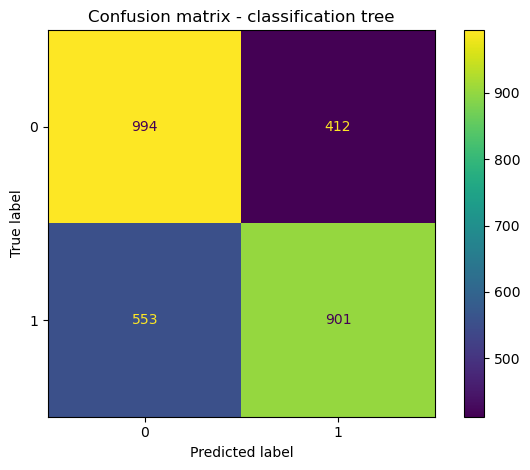

In [13]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

y_true = cls_pred["true_target_improvement_positive"].astype(int)
y_pred = cls_pred["pred_target_improvement_positive"].astype(int)

cm = confusion_matrix(y_true, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.title("Confusion matrix - classification tree")
plt.tight_layout()
plt.show()

## experiment level roc auc

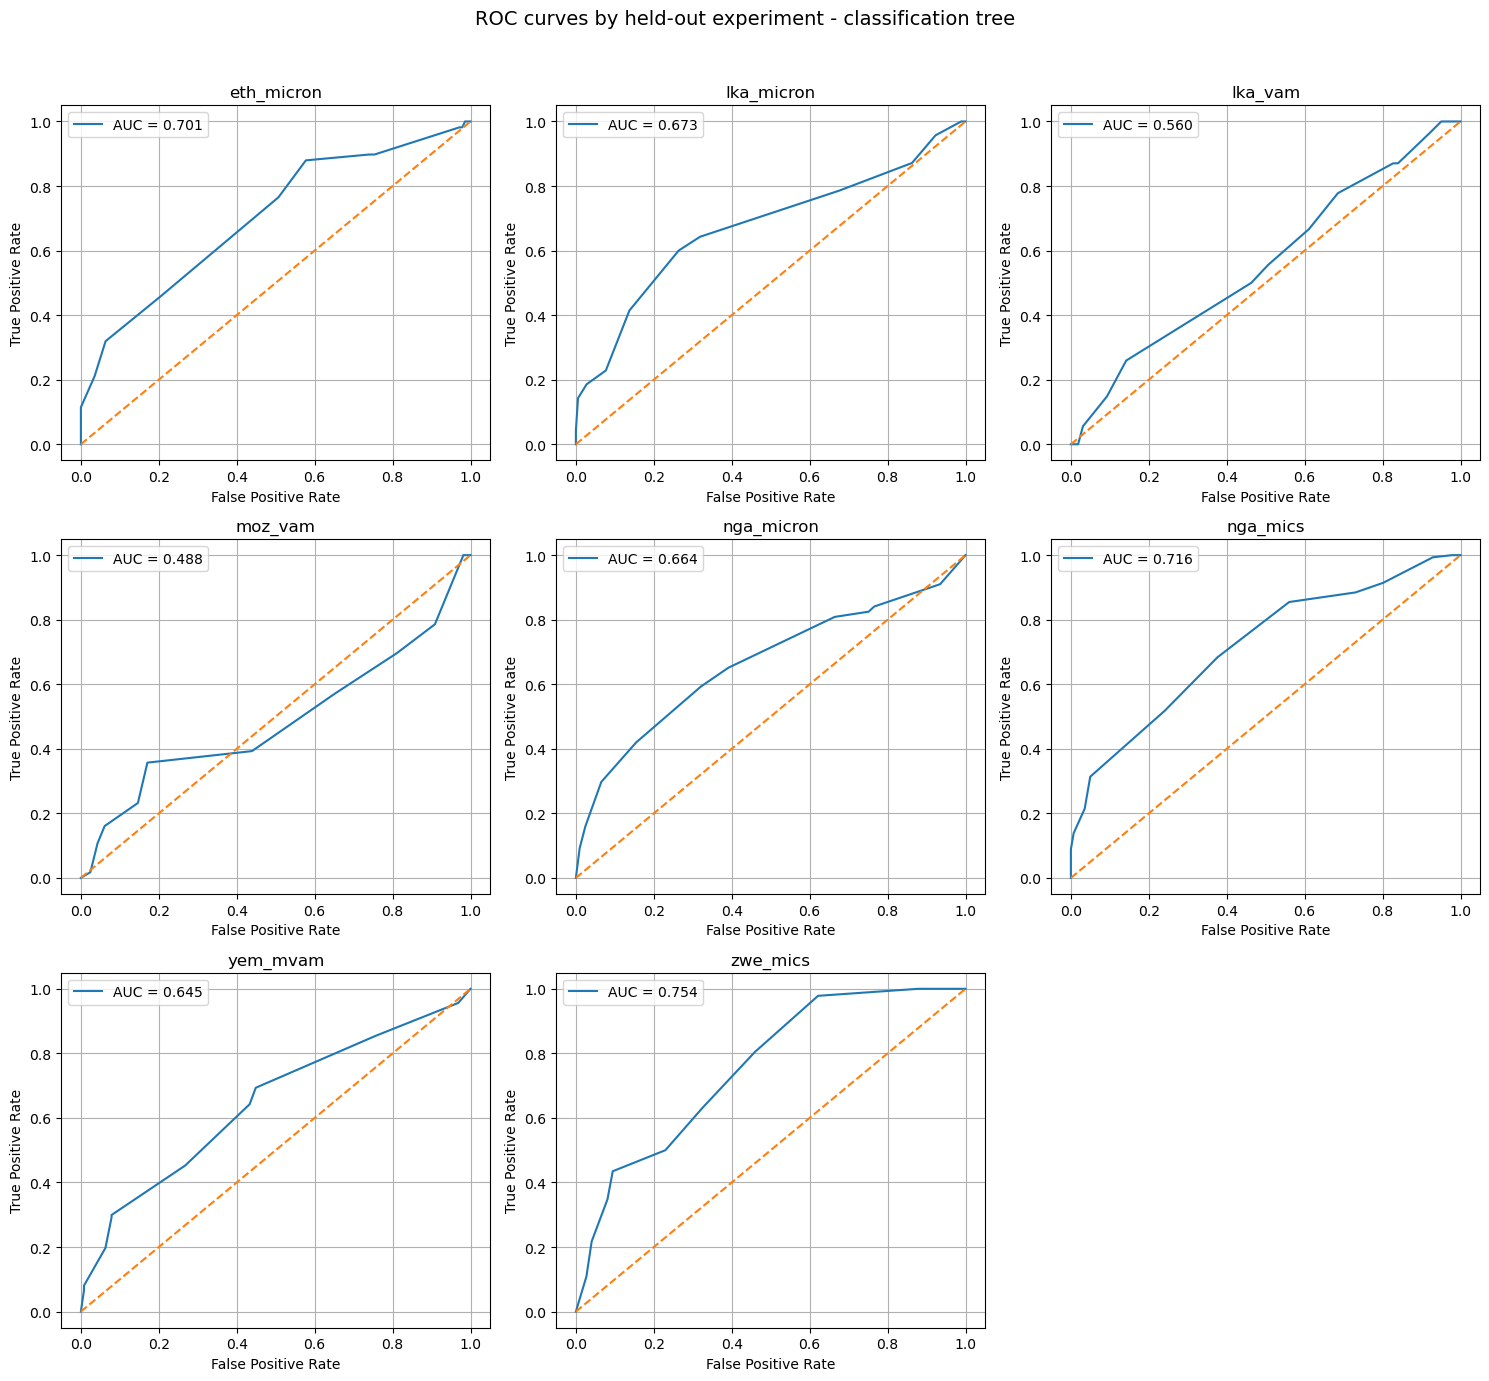

In [14]:
import math
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, roc_auc_score

# assumes cls_pred is already loaded
# cls_pred = pd.read_csv(BASE / "cls_test_predictions.csv")

exp_list = sorted(cls_pred["outer_test_experiment"].dropna().unique().tolist())
n = len(exp_list)

ncols = 3
nrows = math.ceil(n / ncols)

fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 4.5 * nrows))
axes = np.array(axes).reshape(-1)

for ax, exp in zip(axes, exp_list):
    g = cls_pred.loc[cls_pred["outer_test_experiment"] == exp].copy()

    y_true = g["true_target_improvement_positive"].astype(int).values
    y_score = g["pred_proba_target_improvement_positive"].astype(float).values

    if len(np.unique(y_true)) < 2:
        ax.text(0.5, 0.5, f"{exp}\nROC AUC undefined\n(one class only)",
                ha="center", va="center", fontsize=11)
        ax.set_xlim(0, 1)
        ax.set_ylim(0, 1)
        ax.plot([0, 1], [0, 1], linestyle="--")
        ax.set_title(exp)
        ax.set_xlabel("False Positive Rate")
        ax.set_ylabel("True Positive Rate")
        ax.grid(True)
        continue

    fpr, tpr, _ = roc_curve(y_true, y_score)
    auc = roc_auc_score(y_true, y_score)

    ax.plot(fpr, tpr, label=f"AUC = {auc:.3f}")
    ax.plot([0, 1], [0, 1], linestyle="--")
    ax.set_title(exp)
    ax.set_xlabel("False Positive Rate")
    ax.set_ylabel("True Positive Rate")
    ax.legend()
    ax.grid(True)

# hide unused axes
for ax in axes[len(exp_list):]:
    ax.axis("off")

plt.suptitle("ROC curves by held-out experiment - classification tree", y=1.02, fontsize=14)
plt.tight_layout()
plt.show()

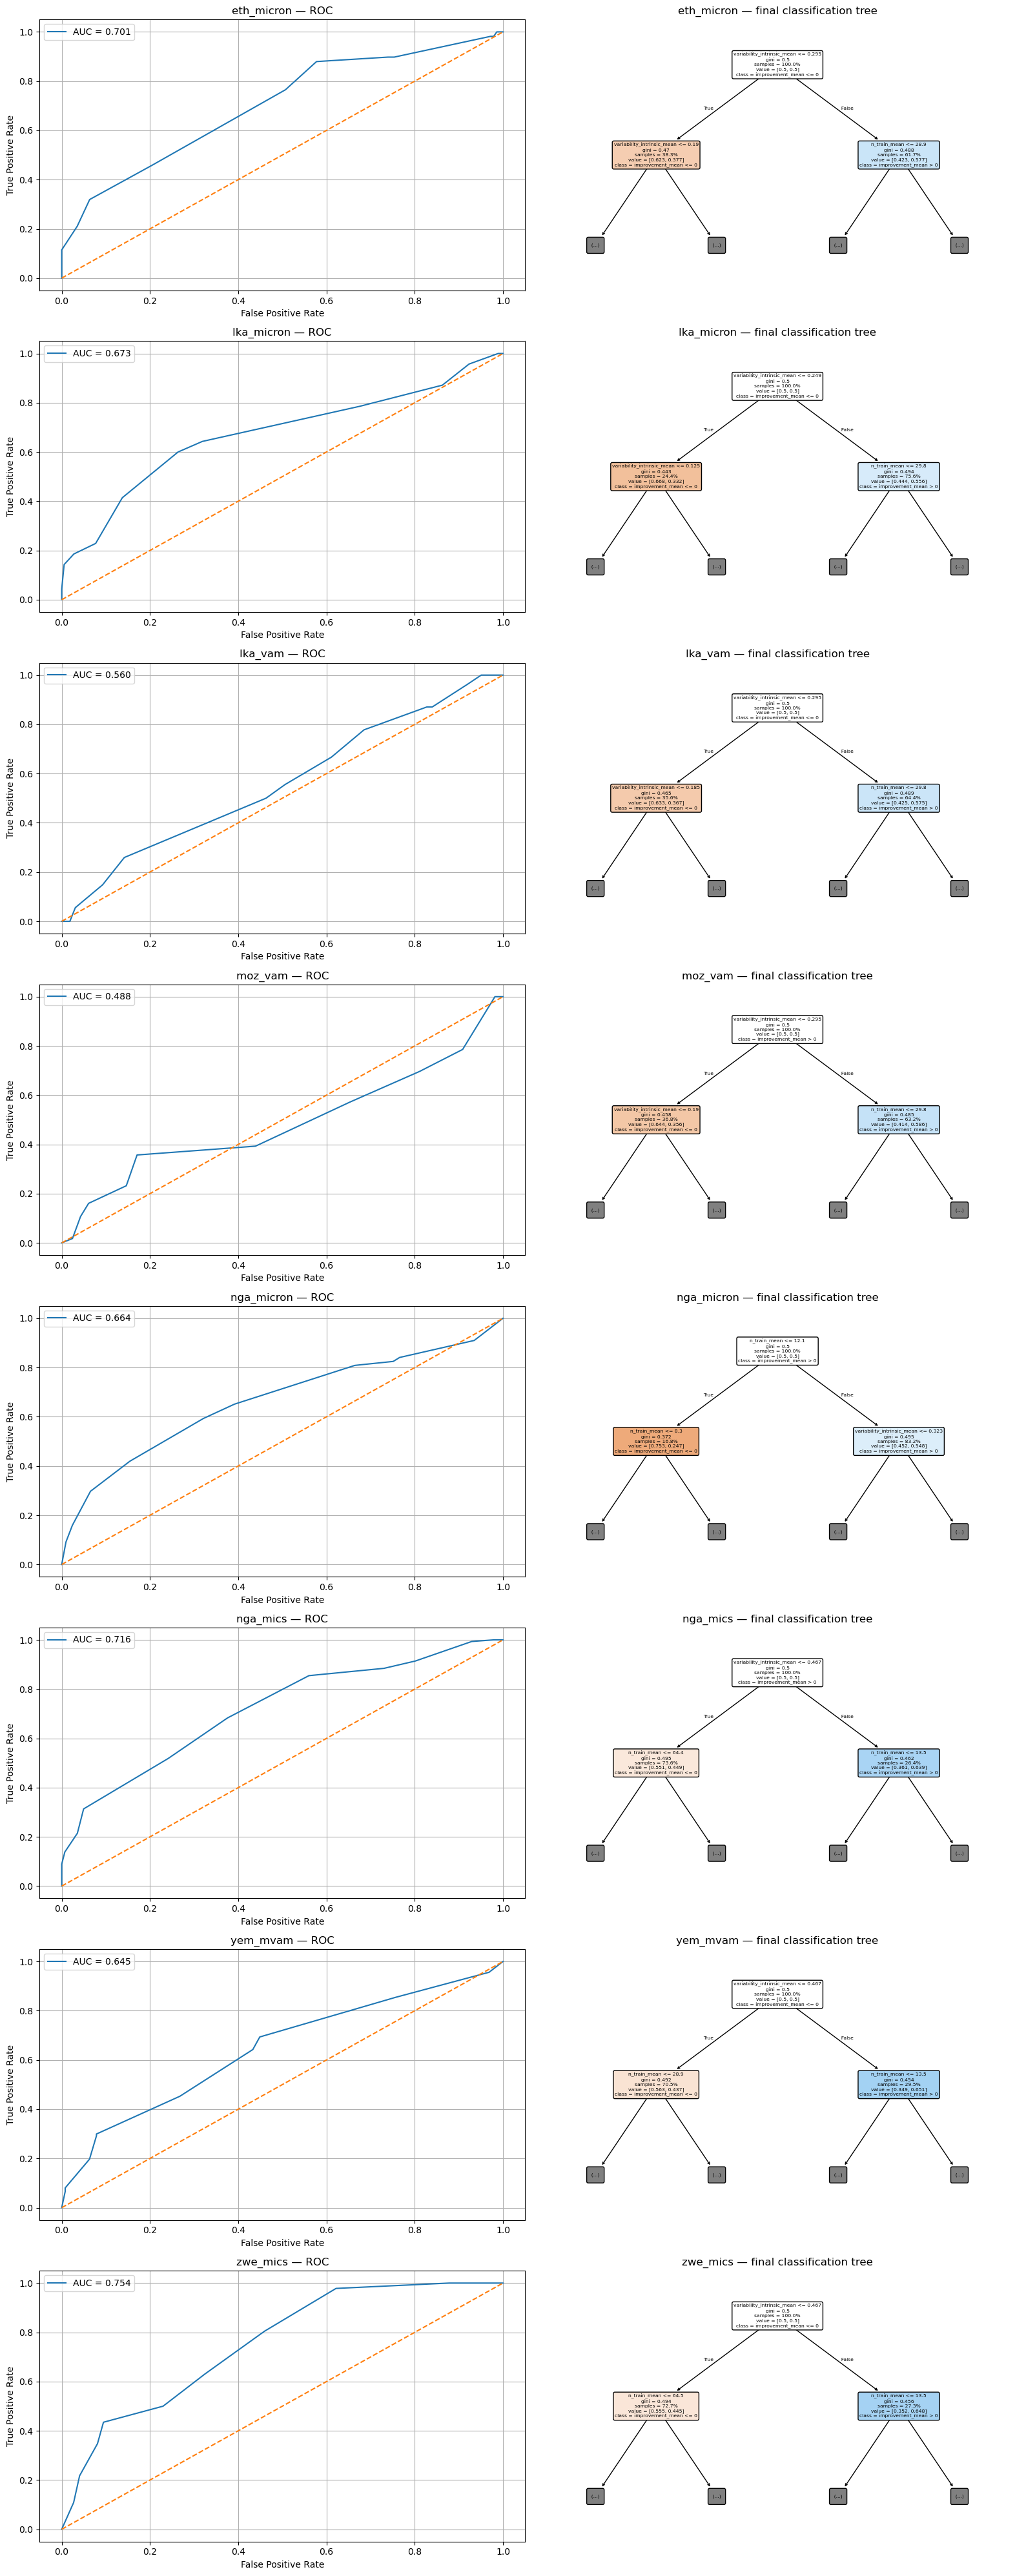

In [15]:
import math
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from joblib import load
from sklearn.metrics import roc_curve, roc_auc_score
from sklearn.tree import plot_tree

BASE = Path("/data/shared/fsibilla/clean_code/Q1/decision_supp_model/tree")

cls_pred = pd.read_csv(BASE / "cls_test_predictions.csv")
cls_fold = pd.read_csv(BASE / "cls_fold_test_metrics.csv")

FEATURE_NAMES = [#"frac", 
                 "variability_intrinsic_mean", 
                 'n_train_mean']
CLASS_NAMES = ["improvement_mean <= 0", "improvement_mean > 0"]

exp_list = sorted(cls_pred["outer_test_experiment"].dropna().unique().tolist())
n = len(exp_list)

# 2 panels per experiment: ROC + tree
ncols = 2
nrows = n

fig, axes = plt.subplots(
    nrows=nrows,
    ncols=ncols,
    figsize=(16, 5 * nrows)
)

# when nrows == 1, axes may not be 2D
axes = np.atleast_2d(axes)

for i, exp in enumerate(exp_list):
    ax_roc = axes[i, 0]
    ax_tree = axes[i, 1]

    # -------------------
    # ROC panel
    # -------------------
    g = cls_pred.loc[cls_pred["outer_test_experiment"] == exp].copy()
    y_true = g["true_target_improvement_positive"].astype(int).values
    y_score = g["pred_proba_target_improvement_positive"].astype(float).values

    if len(np.unique(y_true)) < 2:
        ax_roc.text(
            0.5, 0.5,
            f"{exp}\nROC AUC undefined\n(one class only)",
            ha="center", va="center", fontsize=11
        )
        ax_roc.plot([0, 1], [0, 1], linestyle="--")
        ax_roc.set_xlim(0, 1)
        ax_roc.set_ylim(0, 1)
    else:
        fpr, tpr, _ = roc_curve(y_true, y_score)
        auc = roc_auc_score(y_true, y_score)
        ax_roc.plot(fpr, tpr, label=f"AUC = {auc:.3f}")
        ax_roc.plot([0, 1], [0, 1], linestyle="--")
        ax_roc.legend()

    ax_roc.set_title(f"{exp} — ROC")
    ax_roc.set_xlabel("False Positive Rate")
    ax_roc.set_ylabel("True Positive Rate")
    ax_roc.grid(True)

    # -------------------
    # Tree panel
    # -------------------
    row = cls_fold.loc[cls_fold["outer_test_experiment"] == exp]
    if row.empty:
        ax_tree.text(0.5, 0.5, f"{exp}\nNo saved fold row", ha="center", va="center")
        ax_tree.axis("off")
        continue

    model_path = row["model_path"].iloc[0]

    if pd.isna(model_path) or not Path(model_path).exists():
        ax_tree.text(
            0.5, 0.5,
            f"{exp}\nModel file not found",
            ha="center", va="center", fontsize=11
        )
        ax_tree.axis("off")
        continue

    model = load(model_path)

    plot_tree(
        model,
        feature_names=FEATURE_NAMES,
        class_names=CLASS_NAMES,
        filled=True,
        rounded=True,
        impurity=True,
        proportion=True,
        ax=ax_tree,
        max_depth=1   # increase or remove if you want the full tree
    )
    ax_tree.set_title(f"{exp} — final classification tree")

plt.tight_layout()
plt.show()

## Regression based classifier

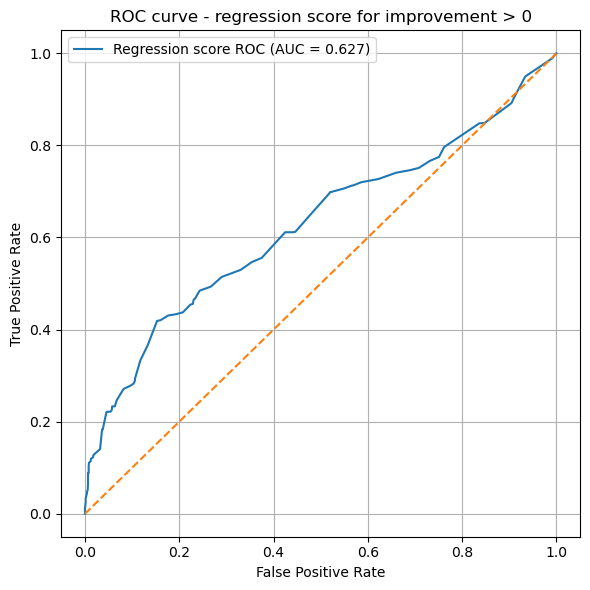

Overall regression-based ROC AUC: 0.6267


In [16]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

# assumes reg_pred is already loaded
reg_pred = pd.read_csv(BASE / "reg_test_predictions.csv")

y_true = (reg_pred["true_improvement_mean"] > 0).astype(int).values
y_score = reg_pred["pred_improvement_mean"].astype(float).values

auc_reg = roc_auc_score(y_true, y_score)
fpr, tpr, _ = roc_curve(y_true, y_score)

plt.figure(figsize=(6, 6))
plt.plot(fpr, tpr, label=f"Regression score ROC (AUC = {auc_reg:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC curve - regression score for improvement > 0")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

print(f"Overall regression-based ROC AUC: {auc_reg:.4f}")

Overall regression-based ROC AUC: 0.6267


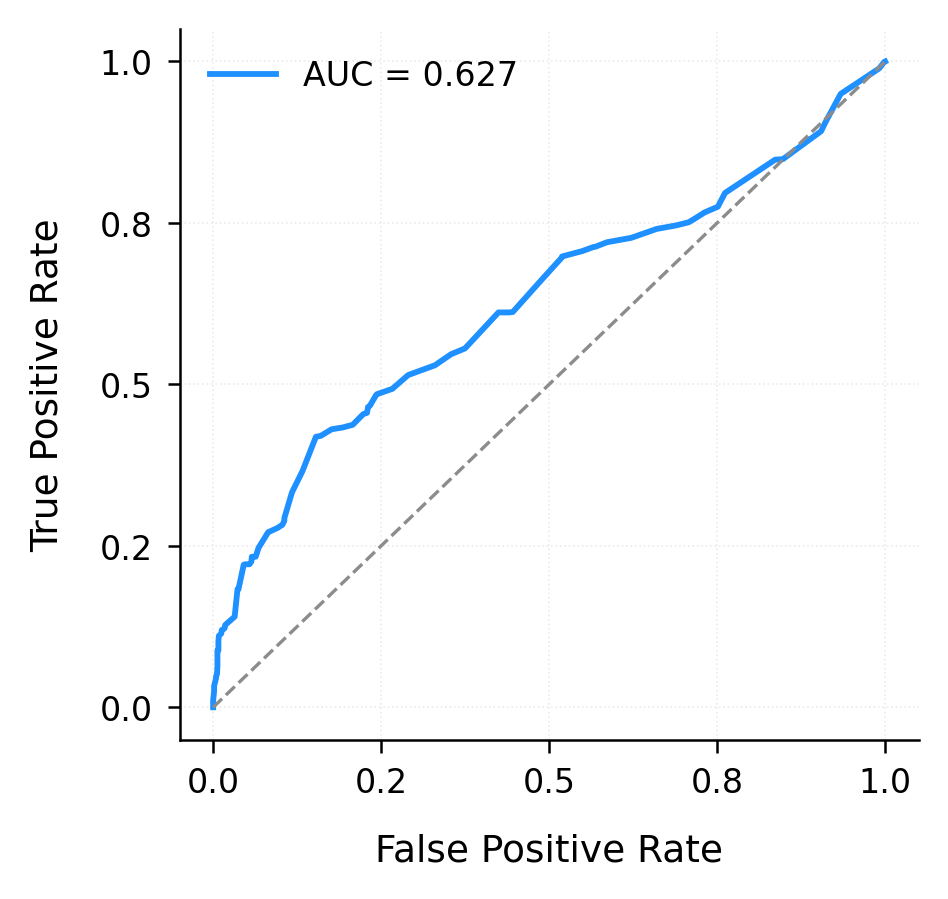

In [17]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

plt.rcParams.update({
    "font.family":        "sans-serif",
    "font.sans-serif":    ["Helvetica", "Arial", "DejaVu Sans"],
    "font.size":          8,
    "axes.labelsize":     9,
    "axes.labelweight":   "normal",
    "axes.titlesize":     9,
    "xtick.labelsize":    8,
    "ytick.labelsize":    8,
    "xtick.major.width":  0.6,
    "ytick.major.width":  0.6,
    "xtick.major.size":   3,
    "ytick.major.size":   3,
    "axes.linewidth":     0.6,
    "axes.spines.top":    False,
    "axes.spines.right":  False,
    "legend.fontsize":    8,
    "legend.frameon":     False,
    "figure.dpi":         300,
    "svg.fonttype":       "none",
})

C_BAYES = "DodgerBlue"

reg_pred = pd.read_csv(BASE / "reg_test_predictions.csv")
y_true  = (reg_pred["true_improvement_mean"] > 0).astype(int).values
y_score = reg_pred["pred_improvement_mean"].astype(float).values

auc_reg = roc_auc_score(y_true, y_score)
fpr, tpr, _ = roc_curve(y_true, y_score)
print(f"Overall regression-based ROC AUC: {auc_reg:.4f}")

# ── Plot ────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(3.2, 3.2))
fig.subplots_adjust(left=0.18, right=0.95, top=0.92, bottom=0.18)

ax.plot(fpr, tpr, color=C_BAYES, linewidth=1.4, label=f"AUC = {auc_reg:.3f}")
ax.plot([0, 1], [0, 1], linestyle="--", color="0.55", linewidth=0.8)

ax.set_xlabel("False Positive Rate", fontsize=9, labelpad=8)
ax.set_ylabel("True Positive Rate", fontsize=9, labelpad=8)
ax.legend(fontsize=8, frameon=False)
ax.grid(axis="both", linewidth=0.4, alpha=0.25, linestyle=":")
ax.xaxis.set_major_formatter(ticker.FormatStrFormatter("%.1f"))
ax.yaxis.set_major_formatter(ticker.FormatStrFormatter("%.1f"))
ax.xaxis.set_major_locator(ticker.MaxNLocator(5))
ax.yaxis.set_major_locator(ticker.MaxNLocator(5))

fig.savefig("roc_regression.svg", bbox_inches="tight")
fig.savefig("roc_regression.png", bbox_inches="tight", dpi=300)
plt.show()

Overall regression-based ROC AUC: 0.6267


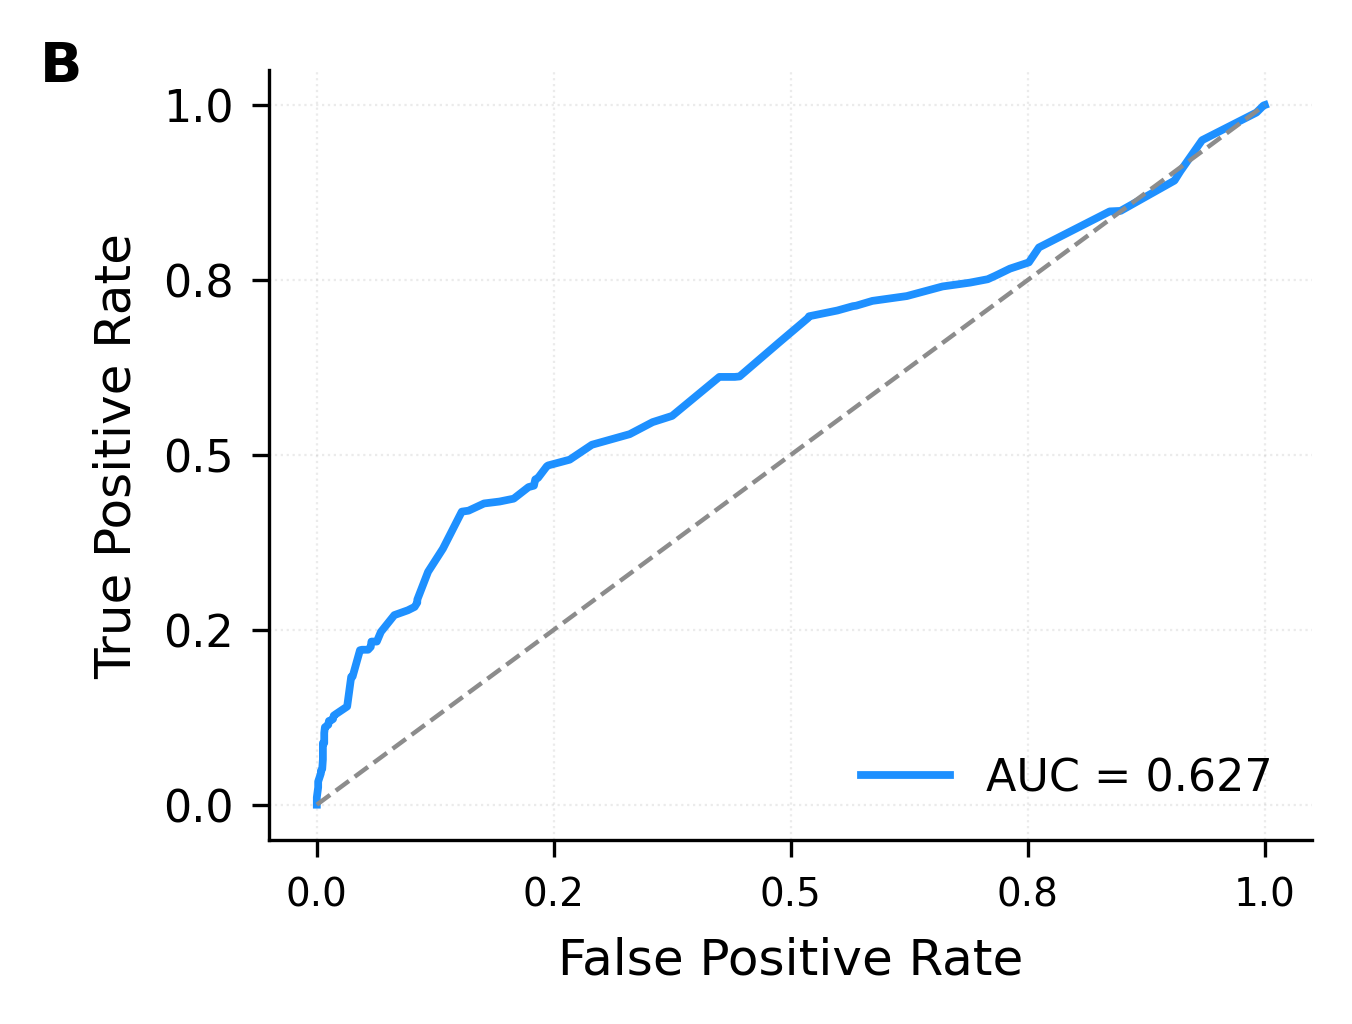

In [19]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

# ── Style — identical to panel A ─────────────────────────────────────────────
plt.rcParams.update({
    "font.family":        "sans-serif",
    "font.sans-serif":    ["Helvetica", "Arial", "DejaVu Sans"],
    "font.size":          8,
    "axes.labelsize":     7,
    "axes.labelweight":   "normal",
    "axes.titlesize":     7,
    "xtick.labelsize":    7,
    "ytick.labelsize":    8,
    "xtick.major.width":  0.6,
    "ytick.major.width":  0.6,
    "xtick.major.size":   3,
    "ytick.major.size":   3,
    "axes.linewidth":     0.6,
    "axes.spines.top":    False,
    "axes.spines.right":  False,
    "legend.fontsize":    8,
    "legend.frameon":     False,
    "figure.dpi":         400,
    "svg.fonttype":       "none",
})

C_BAYES = "DodgerBlue"

reg_pred = pd.read_csv(BASE / "reg_test_predictions.csv")
y_true  = (reg_pred["true_improvement_mean"] > 0).astype(int).values
y_score = reg_pred["pred_improvement_mean"].astype(float).values
auc_reg = roc_auc_score(y_true, y_score)
fpr, tpr, _ = roc_curve(y_true, y_score)
print(f"Overall regression-based ROC AUC: {auc_reg:.4f}")

# ── Figure — same width and margins as panel A ───────────────────────────────
fig, ax = plt.subplots(figsize=(3.3, 2.6))
fig.subplots_adjust(left=0.18, right=0.97, top=0.88, bottom=0.14)

ax.plot(fpr, tpr, color=C_BAYES, linewidth=1.4, label=f"AUC = {auc_reg:.3f}")
ax.plot([0, 1], [0, 1], linestyle="--", color="0.55", linewidth=0.8)

ax.set_xlabel("False Positive Rate", fontsize=9, labelpad=4)
ax.set_ylabel("True Positive Rate", fontsize=9, labelpad=4)

ax.legend(fontsize=8, frameon=False, loc="lower right")

ax.grid(axis="both", linewidth=0.4, alpha=0.25, linestyle=":")
ax.xaxis.set_major_formatter(ticker.FormatStrFormatter("%.1f"))
ax.yaxis.set_major_formatter(ticker.FormatStrFormatter("%.1f"))
ax.xaxis.set_major_locator(ticker.MaxNLocator(5))
ax.yaxis.set_major_locator(ticker.MaxNLocator(5))

# panel letter B — same position as A
ax.text(
    -0.22, 1.04, "B",
    transform=ax.transAxes,
    fontsize=10, fontweight="bold",
    va="top", ha="left"
)

# ── Save ─────────────────────────────────────────────────────────────────────
fig.savefig("roc_regression.png", bbox_inches="tight", dpi=400)
fig.savefig("roc_regression.pdf", bbox_inches="tight")
fig.savefig("roc_regression.svg", bbox_inches="tight")
plt.show()

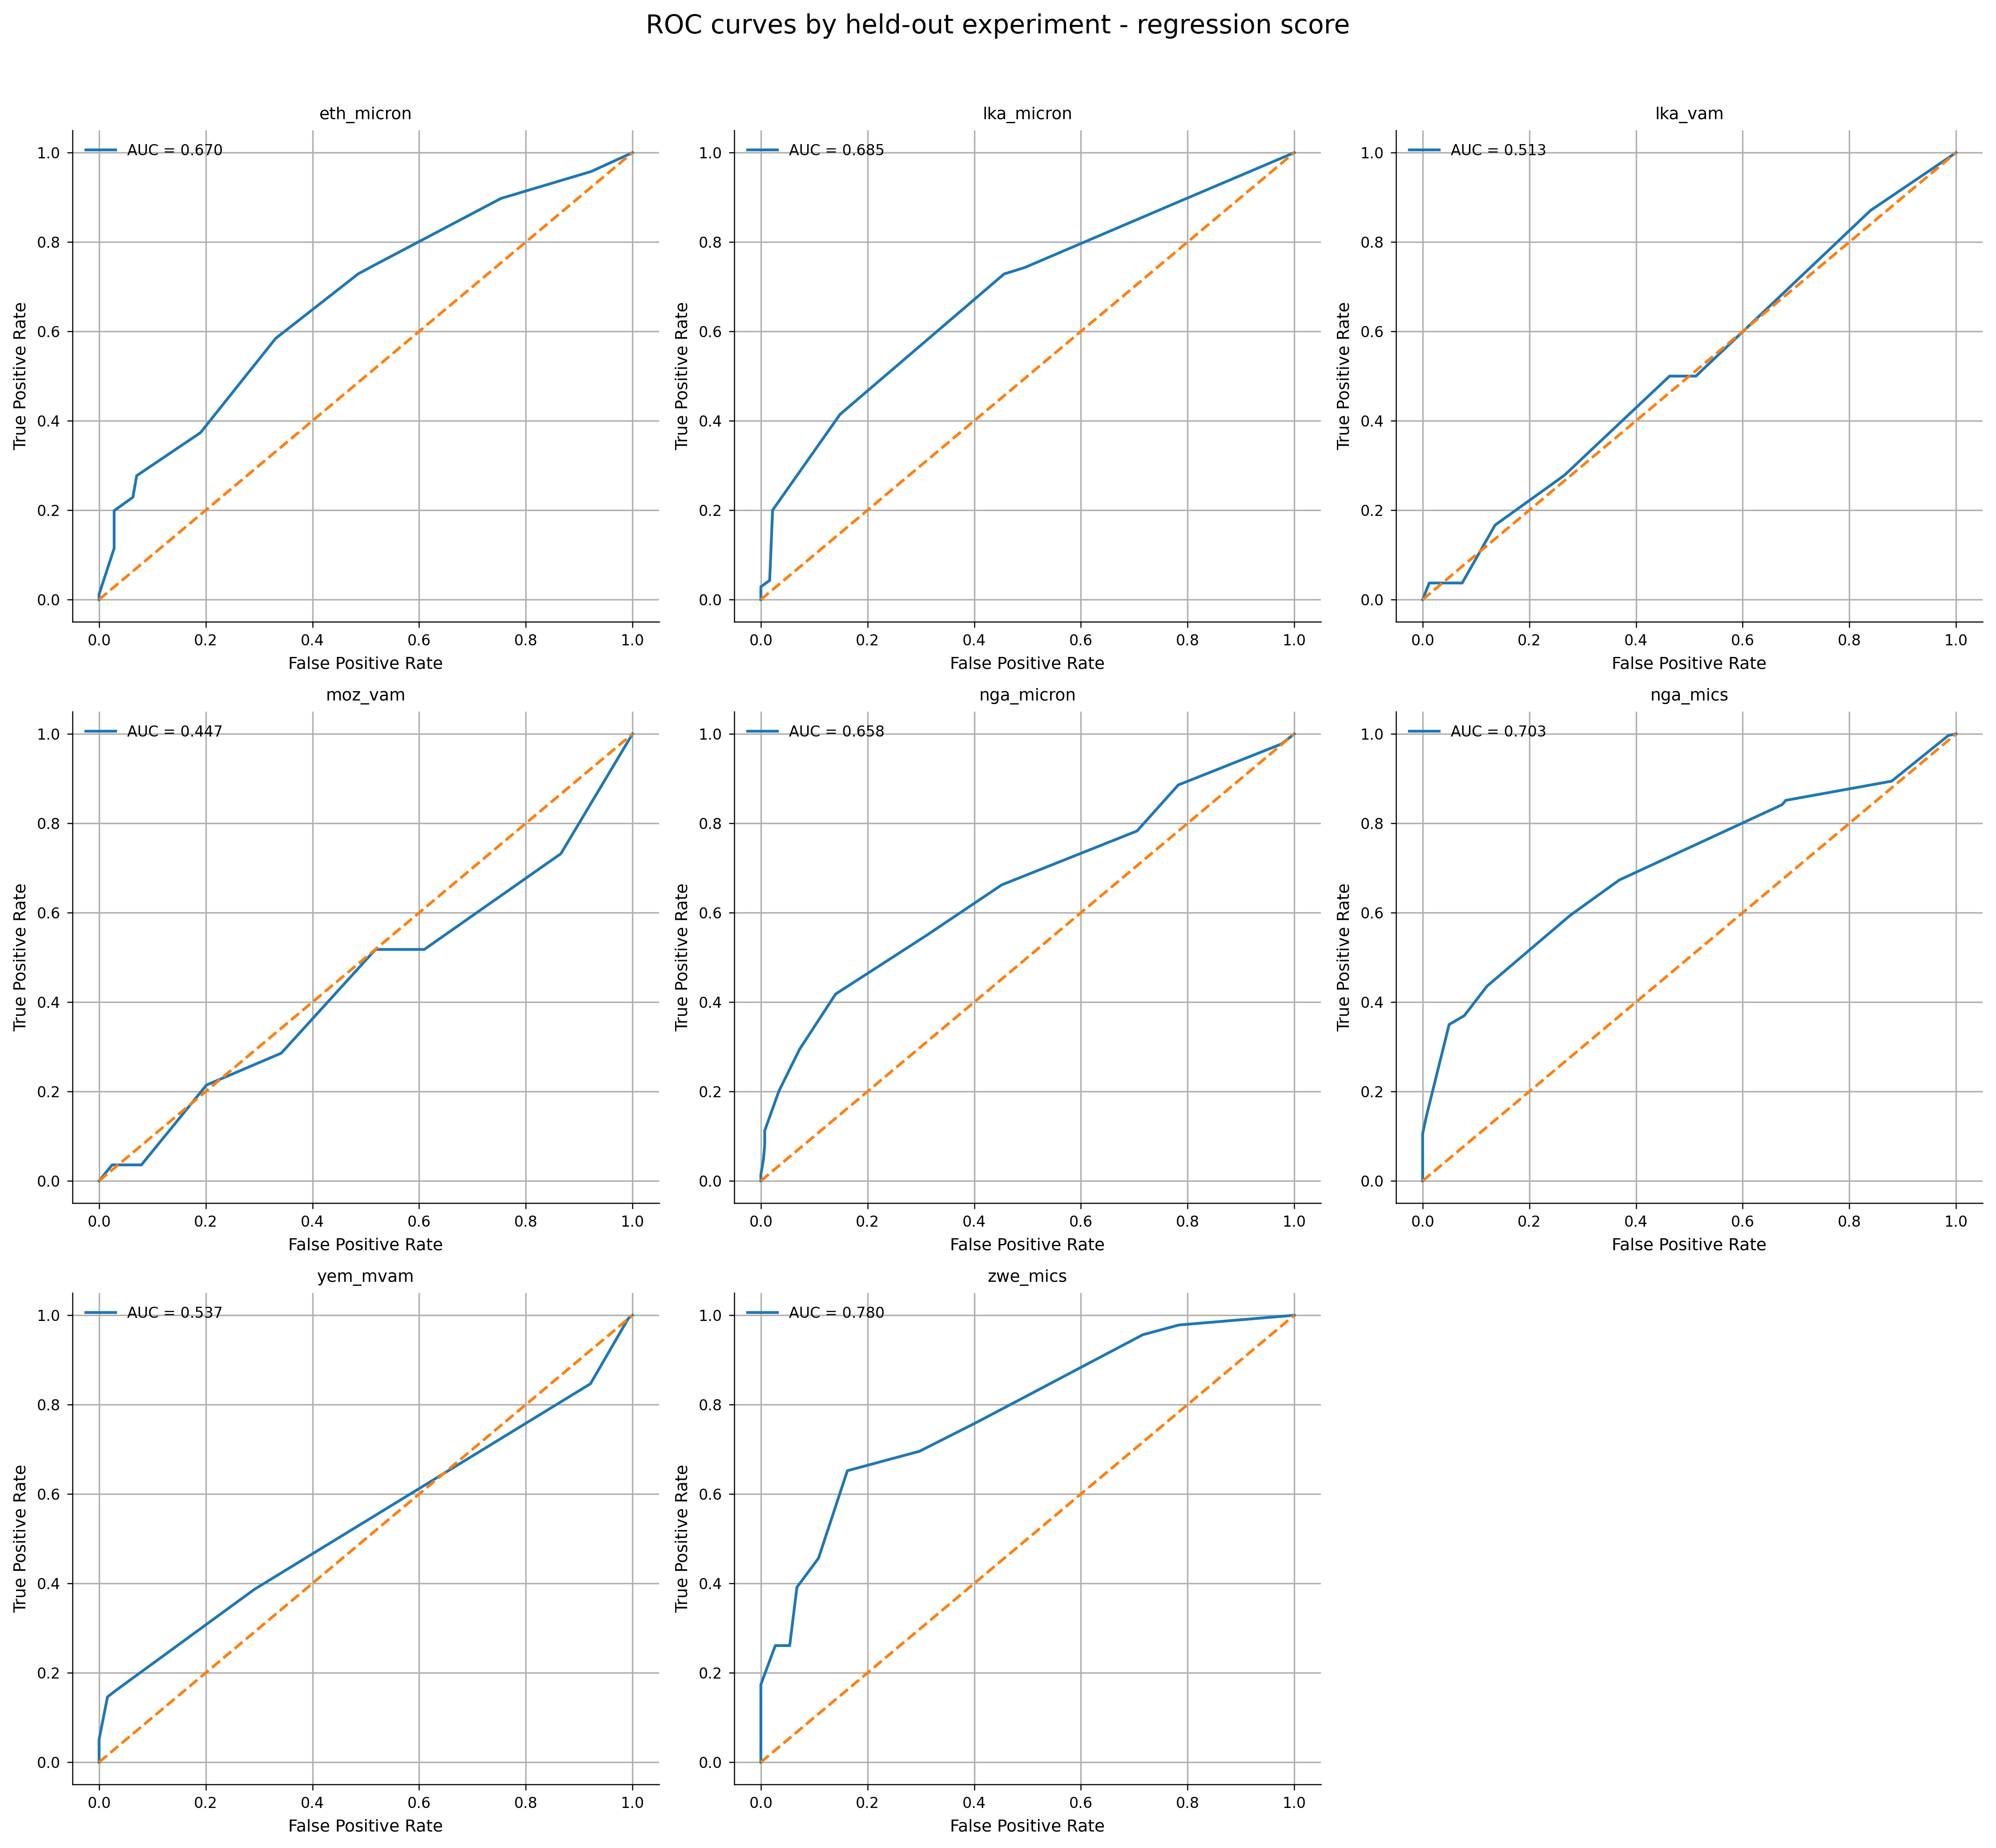

In [18]:
import math
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, roc_auc_score

exp_list = sorted(reg_pred["outer_test_experiment"].dropna().unique().tolist())
n = len(exp_list)

ncols = 3
nrows = math.ceil(n / ncols)

fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 4.5 * nrows))
axes = np.array(axes).reshape(-1)

for ax, exp in zip(axes, exp_list):
    g = reg_pred.loc[reg_pred["outer_test_experiment"] == exp].copy()

    y_true = (g["true_improvement_mean"] > 0).astype(int).values
    y_score = g["pred_improvement_mean"].astype(float).values

    if len(np.unique(y_true)) < 2:
        ax.text(0.5, 0.5, f"{exp}\nROC AUC undefined\n(one class only)",
                ha="center", va="center", fontsize=11)
        ax.set_xlim(0, 1)
        ax.set_ylim(0, 1)
        ax.plot([0, 1], [0, 1], linestyle="--")
        ax.set_title(exp)
        ax.set_xlabel("False Positive Rate")
        ax.set_ylabel("True Positive Rate")
        ax.grid(True)
        continue

    fpr, tpr, _ = roc_curve(y_true, y_score)
    auc = roc_auc_score(y_true, y_score)

    ax.plot(fpr, tpr, label=f"AUC = {auc:.3f}")
    ax.plot([0, 1], [0, 1], linestyle="--")
    ax.set_title(exp)
    ax.set_xlabel("False Positive Rate")
    ax.set_ylabel("True Positive Rate")
    ax.legend()
    ax.grid(True)

for ax in axes[len(exp_list):]:
    ax.axis("off")

plt.suptitle("ROC curves by held-out experiment - regression score", y=1.02, fontsize=14)
plt.tight_layout()
plt.show()